# Aufgabe 12.3 – Regressionsmodell für Endgewicht

Ziel: Vorhersage des Endgewichts (`final_weight`) einer Flasche anhand von Sensordaten (Füllstand, Vibrationsindex, Temperatur).

Trainiert wird auf den eigenen gesammelten Daten aus Aufgabe 12.1.2.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

## 1. Daten laden

In [6]:
df = pd.read_csv('data.csv')

# Spaltennamen angleichen (data.csv hat temperature_C_red, X.csv hat temperature_red)
df = df.rename(columns={
    'temperature_C_red':   'temperature_red',
    'temperature_C_blue':  'temperature_blue',
    'temperature_C_green': 'temperature_green',
})

df = df.dropna(subset=['final_weight'])

print(f'Flaschen gesamt: {len(df)}')
df.head()

Flaschen gesamt: 636


,bottle,recipe,fill_level_grams_red,vibration_index_red,time_red,temperature_red,fill_level_grams_blue,vibration_index_blue,time_blue,temperature_blue,fill_level_grams_green,vibration_index_green,time_green,temperature_green,final_weight,time_scale,is_cracked,drop_oscillation
0,80585489,3,623.240892,86.722805,1780650235,32.355647,846.736547,-21.523238,1780650239,33.482129,0.000000,-15.432611,1780650243,32.716305,10.422501,1780650245,0,"['0.0000000000', '0.8265280184', '1.2577888062..."
1,80585491,3,616.626970,83.834205,1780650239,32.644641,846.495462,-15.780005,1780650243,32.573862,788.343641,158.883278,1780650247,32.658978,28.394977,1780650249,0,"['0.0000000000', '-0.0042422357', '0.211720551..."
2,80585493,3,610.103457,82.510405,1780650243,32.178065,846.135847,-12.192027,1780650247,31.740672,776.171876,164.606564,1780650251,33.929484,29.178344,1780650253,0,"['0.0000000000', '0.3612517982', '0.6557609528..."
3,80585495,3,603.994296,75.884466,1780650247,33.011491,846.269521,-23.479519,1780650251,33.571221,764.079516,161.128019,1780650255,31.624994,27.102009,1780650257,1,"['0.0048625487', '0.0427484016', '-0.047658659..."
4,80585497,3,597.054817,88.889993,1780650251,31.615878,845.615286,-10.848786,1780650255,33.182353,752.853846,158.316487,1780650259,32.700117,29.233201,1780650261,0,"['-0.0000000000', '0.1727070637', '-0.58941657..."


## 2. Feature-Kombinationen testen

Wir testen sechs verschiedene Kombinationen von Eingabe-Features und berechnen jeweils den MSE (Mean Squared Error) auf Trainings- und Testdaten.

**80% Training, 20% Test** — der Test-MSE zeigt wie gut das Modell auf neuen, unbekannten Daten ist.

In [7]:
y = df['final_weight']

feature_sets = [
    ['fill_level_grams_red'],
    ['fill_level_grams_red', 'vibration_index_red'],
    ['fill_level_grams_red', 'vibration_index_red', 'temperature_red'],
    ['fill_level_grams_red', 'fill_level_grams_blue', 'fill_level_grams_green'],
    ['fill_level_grams_red', 'fill_level_grams_blue', 'fill_level_grams_green',
     'vibration_index_red', 'vibration_index_blue', 'vibration_index_green'],
    ['fill_level_grams_red', 'fill_level_grams_blue', 'fill_level_grams_green',
     'vibration_index_red', 'vibration_index_blue', 'vibration_index_green',
     'temperature_red', 'temperature_blue', 'temperature_green'],
]

results = []
best_mse   = float('inf')
best_model = None
best_features = None

for features in feature_sets:
    X = df[features].dropna()
    y_clean = y[X.index]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_clean, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    mse_train = mean_squared_error(y_train, model.predict(X_train))
    mse_test  = mean_squared_error(y_test,  model.predict(X_test))

    results.append({
        'Spalten (X)': ', '.join(features),
        'Modell':      'Linear',
        'MSE Train':   round(mse_train, 4),
        'MSE Test':    round(mse_test, 4),
    })

    if mse_test < best_mse:
        best_mse      = mse_test
        best_model    = model
        best_features = features

pd.DataFrame(results)

,Spalten (X),Modell,MSE Train,MSE Test
0,fill_level_grams_red,Linear,50.2053,76.0945
1,"fill_level_grams_red, vibration_index_red",Linear,46.1835,72.8148
2,"fill_level_grams_red, vibration_index_red, tem...",Linear,46.1195,72.4314
3,"fill_level_grams_red, fill_level_grams_blue, f...",Linear,36.7725,45.9881
4,"fill_level_grams_red, fill_level_grams_blue, f...",Linear,0.1185,0.1369
5,"fill_level_grams_red, fill_level_grams_blue, f...",Linear,0.0000,0.0000


## 3. Bestes Modell & Formel

In [8]:
print(f'Bestes Modell: {best_features}')
print(f'MSE Test:      {best_mse:.4f}')
print()
print('Formel: y = ')
for coef, feat in zip(best_model.coef_, best_features):
    print(f'  {coef:.4f} * {feat}')
print(f'  + {best_model.intercept_:.4f}')

Bestes Modell: ['fill_level_grams_red', 'fill_level_grams_blue', 'fill_level_grams_green', 'vibration_index_red', 'vibration_index_blue', 'vibration_index_green', 'temperature_red', 'temperature_blue', 'temperature_green']
MSE Test:      0.0000

Formel: y = 
  0.0005 * fill_level_grams_red
  0.0005 * fill_level_grams_blue
  0.0005 * fill_level_grams_green
  0.1000 * vibration_index_red
  0.1000 * vibration_index_blue
  0.1000 * vibration_index_green
  0.2000 * temperature_red
  0.2000 * temperature_blue
  0.2000 * temperature_green
  + -15.0000


## 4. Visualisierung: Vorhersage vs. tatsächliches Endgewicht

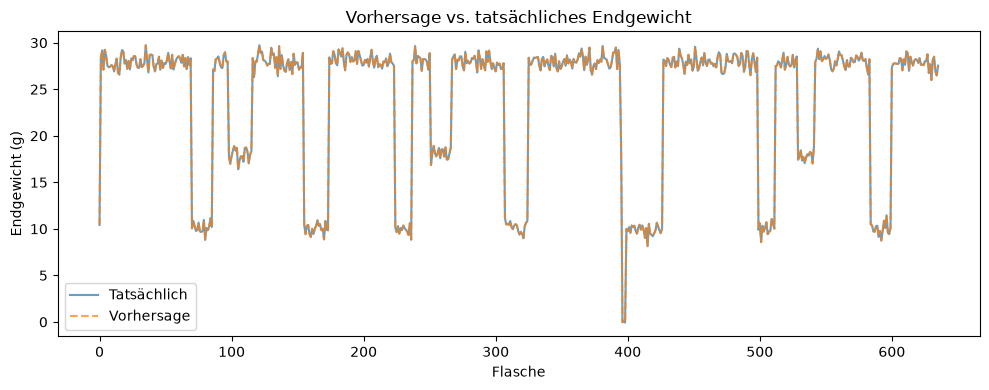

In [9]:
X_all = df[best_features].dropna()
y_all = y[X_all.index]
y_pred = best_model.predict(X_all)

plt.figure(figsize=(10, 4))
plt.plot(y_all.values, label='Tatsächlich', alpha=0.7)
plt.plot(y_pred,       label='Vorhersage',  alpha=0.7, linestyle='--')
plt.xlabel('Flasche')
plt.ylabel('Endgewicht (g)')
plt.title('Vorhersage vs. tatsächliches Endgewicht')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Prognose auf X.csv

In [10]:
X_pred = pd.read_csv('X.csv')

X_pred = X_pred.rename(columns={
    'temperature_C_red':   'temperature_red',
    'temperature_C_blue':  'temperature_blue',
    'temperature_C_green': 'temperature_green',
})

y_hat = best_model.predict(X_pred[best_features])

result = pd.DataFrame({
    'Flaschen ID': X_pred['bottle'],
    'y_hat':       y_hat
})

result.to_csv('reg_SiJuLe.csv', index=False)
print(f'Prognose gespeichert: reg_SiJuLe.csv ({len(result)} Flaschen)')
result.head(10)

Prognose gespeichert: reg_SiJuLe.csv (247 Flaschen)


,Flaschen ID,y_hat
0,368,52.675604
1,369,50.784098
2,370,50.953197
3,371,27.542095
4,372,27.268854
5,373,28.212686
6,374,28.459288
7,375,27.196534
8,376,27.878464
9,377,28.211633
